In [5]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

In [2]:
env = gym.make("FrozenLake-v1", is_slippery=False, map_name="4x4")

n_states = env.observation_space.n
n_actions = env.action_space.n

print("Number of states:", n_states)
print("Number of actions:", n_actions)

Number of states: 16
Number of actions: 4


In [3]:
num_episodes = 20000

gamma = 0.99
alpha = 0.1

epsilon_start = 1.0
epsilon_min = 0.05
epsilon_decay = 0.9995

max_steps_per_episode = 100

In [4]:
Q = np.zeros((n_states, n_actions))

episode_rewards = []

def epsilon_greedy_action(state, epsilon):
    if np.random.random() < epsilon:
        return env.action_space.sample()

    best_actions = np.flatnonzero(Q[state] == np.max(Q[state]))

    return np.random.choice(best_actions)

In [6]:
def generate_episode(epsilon):
    episode = []
    state, info = env.reset()
    for _ in range(max_steps_per_episode):
        action = epsilon_greedy_action(state, epsilon)
        next_state, reward, terminated, truncated, info = env.step(action)
        episode.append((state, action, reward))
        state = next_state
        if terminated or truncated:
            break
    return episode

epsilon = epsilon_start
for episode_num in range(num_episodes):
    episode = generate_episode(epsilon)
    episode_rewards.append(sum(reward for _, _, reward in episode))
    G = 0.0
    visited = set()
    for t in range(len(episode) - 1, -1, -1):
        state, action, reward = episode[t]
        G = gamma * G + reward
        if (state, action) not in visited:
            visited.add((state, action))
            Q[state, action] += alpha * (G - Q[state, action])

    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    if (episode_num + 1) % 2000 == 0:

        avg_reward = np.mean(episode_rewards[-1000:])

        print(
            f"Episode {episode_num + 1:5d} | "
            f"epsilon = {epsilon:.3f} | "
            f"last-1000 average reward = {avg_reward:.3f}"
        )



optimal_policy = np.argmax(Q, axis=1)

state_values = np.max(Q, axis=1)

Episode  2000 | epsilon = 0.368 | last-1000 average reward = 0.374
Episode  4000 | epsilon = 0.135 | last-1000 average reward = 0.783
Episode  6000 | epsilon = 0.050 | last-1000 average reward = 0.921
Episode  8000 | epsilon = 0.050 | last-1000 average reward = 0.931
Episode 10000 | epsilon = 0.050 | last-1000 average reward = 0.942
Episode 12000 | epsilon = 0.050 | last-1000 average reward = 0.945
Episode 14000 | epsilon = 0.050 | last-1000 average reward = 0.938
Episode 16000 | epsilon = 0.050 | last-1000 average reward = 0.937
Episode 18000 | epsilon = 0.050 | last-1000 average reward = 0.938
Episode 20000 | epsilon = 0.050 | last-1000 average reward = 0.937



Final Q-table:
[[0.731 0.448 0.947 0.702]
 [0.673 0.    0.956 0.78 ]
 [0.809 0.966 0.719 0.787]
 [0.727 0.    0.386 0.487]
 [0.586 0.557 0.    0.604]
 [0.    0.    0.    0.   ]
 [0.    0.976 0.    0.838]
 [0.    0.    0.    0.   ]
 [0.662 0.    0.718 0.641]
 [0.793 0.956 0.802 0.   ]
 [0.939 0.99  0.    0.884]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.98  0.99  0.969]
 [0.979 0.99  1.    0.979]
 [0.    0.    0.    0.   ]]

Estimated State-Value Function:
[[0.947 0.956 0.966 0.727]
 [0.604 0.    0.976 0.   ]
 [0.718 0.956 0.99  0.   ]
 [0.    0.99  1.    0.   ]]
Name: Sanjay Balaji S
Register Number: 212223240149

Learned Policy:
[['R' 'R' 'D' 'L']
 ['U' 'L' 'D' 'L']
 ['R' 'D' 'D' 'L']
 ['L' 'R' 'R' 'L']]

Average reward over last 1000 episodes: 0.937


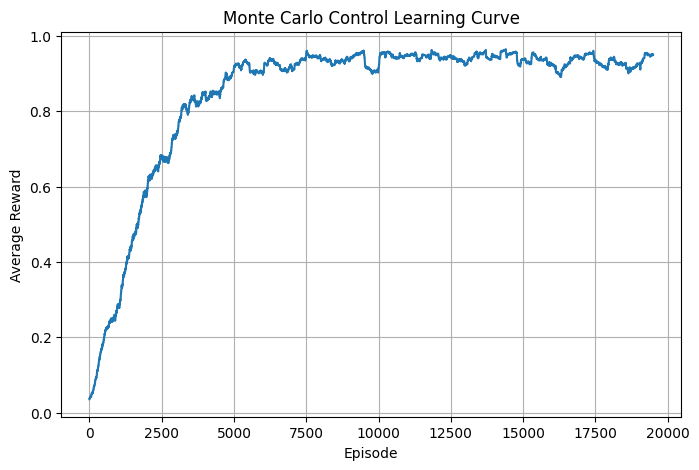

In [7]:
def print_policy(policy):
    action_symbols = {0: "L", 1: "D", 2: "R", 3: "U"}
    policy_grid = np.array([action_symbols[action] for action in policy]).reshape(4, 4)
    print("Name: Sanjay Balaji S")
    print("Register Number: 212223240149")
    print("\nLearned Policy:")
    print(policy_grid)


def print_value_function(values):
    print("\nEstimated State-Value Function:")
    print(np.round(values.reshape(4, 4), 3))

print("\nFinal Q-table:")
print(np.round(Q, 3))
print_value_function(state_values)
print_policy(optimal_policy)
success_rate = np.mean(episode_rewards[-1000:])
print("\nAverage reward over last 1000 episodes:", success_rate)

window = 500
moving_average = np.convolve(episode_rewards, np.ones(window) / window, mode="valid")
plt.figure(figsize=(8, 5))
plt.plot(moving_average)
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("Monte Carlo Control Learning Curve")
plt.grid(True)
plt.show()

env.close()